# Testing the package on London Airbnb Prices dataset

### <span style="color: skyblue;"> Finding the relation between neighbourhoods and the price of the property?  </span>

## Loading the dataset using pandas

In [2]:
import pandas as pd

data = pd.read_csv("../data/London_Airbnb.csv")

data.sample(n=5)

,neighbourhood,room_type,price,minimum_nights
17948,Brent,Private room,21,7
3770,Westminster,Private room,57,3
66149,Hackney,Entire home/apt,72,1
6395,Tower Hamlets,Private room,30,7
32964,Greenwich,Entire home/apt,100,2


## Describing our dataset

In [5]:
dataset_description = "This dataset contains information about properties in London that are available on Airbnb."

column_description = {
    "neighbourhood": "The neighbourhood in which the property is located",
    "room_type": "The type of room available",
    "price": "The price of the property",
    "minimum_nights": "The minimum number of nights that can be booked"
}

## Setting up the LLM using Langchain (gpt-4-turbo)

In [6]:
import os
from dotenv import load_dotenv
from autoinsight.dataset.basic import BaseDataset
from langchain_openai import ChatOpenAI

load_dotenv("../.env")

llm = ChatOpenAI(
        model="gpt-4-turbo",
        openai_api_key=os.getenv("OPENAI_KEY"),
)

dataset_descr = BaseDataset(
        columns_description=column_description,
        data=data,
        description=dataset_description,
        name="London Airbnb",
)

## Applying the groupby operation built in our package

In [3]:
from autoinsight.operations.eda import CategoricalGroupBy

data_copy = data.copy()

categorical_cols = ["neighbourhood", "room_type"]
numerical_cols = ["price", "minimum_nights"]

data_copy[numerical_cols] = data_copy[numerical_cols].apply(pd.to_numeric, errors="coerce")
data_copy = data_copy[data_copy["price"] != 0]

data_copy.dropna(inplace=True)

operation = CategoricalGroupBy(data=data_copy, categorical_columns=categorical_cols, numerical_columns=numerical_cols)

operation =  operation.run_operation()

operation.head()

,price_mean,price_count,price_std,price_min,price_max,minimum_nights_mean,minimum_nights_count,minimum_nights_std,minimum_nights_min,minimum_nights_max
neighbourhood_Barking and Dagenham,96.411085,433,120.458526,10.0,2000.0,4.457275,433,9.776372,1.0,112.0
neighbourhood_Barnet,155.763535,1607,324.308482,8.0,8000.0,7.563783,1607,42.210933,1.0,1000.0
neighbourhood_Bexley,89.686131,411,87.162933,9.0,606.0,4.051095,411,11.942129,1.0,170.0
neighbourhood_Brent,206.323330,2066,407.105446,9.0,7693.0,5.891578,2066,33.551245,1.0,1000.0
neighbourhood_Bromley,112.947635,592,270.572800,10.0,6000.0,3.790541,592,7.382701,1.0,90.0


## Changing the operation prompt for personalized results.

In [21]:
operation.prompt = "I want to understand the relationship between the neighborhood and property prices, including reasons for this correlation. Could you provide an example?\n\n" + operation.prompt
print(operation.prompt)

i wanna know just know the relation between the neighbourhood and the price of the property. what are the resaons for that and give an example

Analyze the following dataset that represent the groupby operation results,
        I want you to extract insights and patterns from the data.
        The result of your analysis need to be based on facts and not on your opinion.
        Group by analysis:
                                              price_mean  price_count   price_std  price_min  price_max  minimum_nights_mean  minimum_nights_count  minimum_nights_std  minimum_nights_min  minimum_nights_max
neighbourhood_Barking and Dagenham     96.411085          433  120.458526       10.0     2000.0             4.457275                   433            9.776372                 1.0               112.0
neighbourhood_Barnet                  155.763535         1607  324.308482        8.0     8000.0             7.563783                  1607           42.210933                 1.0              1

## Sending the new prompt with the context to the model

In [22]:
from autoinsight.analysis.operation_analysis import analyze_single_operation
from IPython.display import  Markdown

response = analyze_single_operation(
    operation=operation,
    dataset=dataset_descr,
    llm=llm,
)

Markdown(response)

From the provided dataset and its group-by analysis, we can extract insights into the relationship between the neighborhood of a property in London and its pricing on Airbnb. Here are some findings and possible reasons for the observed patterns:

### Key Insights:

1. **Variation in Average Prices Across Neighborhoods**:
   - **High Average Price Neighborhoods**: Notable neighborhoods like Kensington and Chelsea, Westminster, and the City of London have higher average prices (mean price of £303, £297, and £269 respectively). These areas are known for their prime locations, affluent surroundings, historical significance, and proximity to central London attractions.
   - **Lower Average Price Neighborhoods**: Conversely, neighborhoods like Barking and Dagenham, Bexley, and Sutton show lower average prices (mean prices of £96, £90, and £85 respectively). These areas are generally more suburban, with less direct access to central London.

2. **Price Dispersion Indicated by Standard Deviation**:
   - High standard deviations in areas like Kensington and Chelsea (558), Westminster (477), and Hammersmith and Fulham (767) indicate a wide range of property prices. This variability can be attributed to a mix of luxury accommodations and more standard offerings within these high-profile areas.
   - Lower standard deviations in areas like Sutton (75) or Bexley (87) suggest more uniform pricing, likely due to a more homogeneous type of property listing in these regions.

3. **Minimum Nights**:
   - Neighborhoods with higher pricing like Kensington and Chelsea have a higher average minimum nights (about 7 nights), which might indicate a preference or policy aimed at longer stays, possibly to cater to tourists or business travelers looking for a more stable accommodation.
   - Conversely, neighborhoods with lower average prices tend to have shorter minimum nights requirements, making them more accessible for shorter and potentially more frequent stays.

### Possible Reasons Behind the Patterns:

1. **Tourist Attractions and Business Centers**:
   - Neighborhoods closer to central London and major tourist attractions (such as Westminster, Camden, and City of London) command higher prices due to higher demand from tourists and business travelers.

2. **Residential Character and Accessibility**:
   - More residential and less centrally located neighborhoods (like Sutton and Bexley) tend to have lower prices. These areas might attract a different demographic, such as visitors looking for longer-term stays or locals needing temporary accommodations.

3. **Property Types and Listings**:
   - Areas with a higher standard deviation in price often have a diverse range of property types, from luxury apartments to more modest accommodations. For example, Kensington and Chelsea's high standard deviation suggests a significant variety in the type of accommodations offered, reflecting the economic diversity and varying tourist expectations in the area.

### Example:
Consider the neighborhood of Kensington and Chelsea, known for its luxurious properties and proximity to central London landmarks. The high average price (£303) and wide range of property prices (standard deviation of 558) reflect the premium location and the diversity of properties available, from high-end apartments to more affordable rooms. This neighborhood's pricing strategy might be influenced by its appeal to wealthier tourists and residents desiring a prestigious London experience.

In summary, the relationship between neighborhood and property pricing on Airbnb in London is influenced by factors such as location proximity to central areas, local attractions, type of neighborhood, and the diversity of accommodations available. This analysis helps understand how different areas cater to varying market segments and traveler needs.

## Validating certain results to ensure the LLM is providing accurate answers

<span style="color:lightblue;"> -> High Average Price Neighborhoods: Notable neighborhoods like Kensington and Chelsea, Westminster, and the City of London have higher average prices (mean price of £303, £297, and £269 respectively). These areas are known for their prime locations, affluent surroundings, historical significance, and proximity to central London attractions. </span>

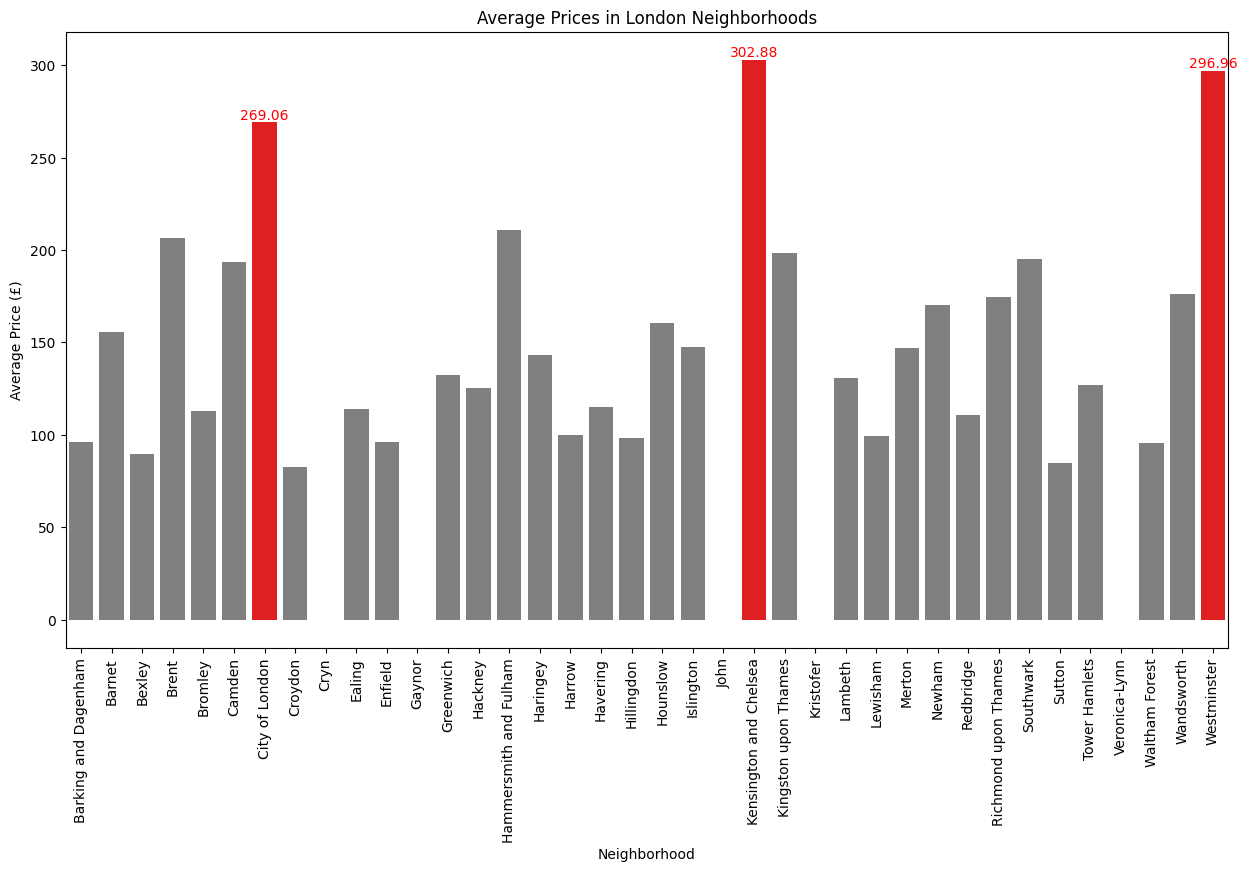

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("../data/London_Airbnb.csv")

data["price"] = pd.to_numeric(data["price"], errors="coerce")

data = data.dropna(subset=["price"])

avg_prices = data.groupby("neighbourhood")["price"].mean().reset_index()

target_neighborhoods = ["Kensington and Chelsea", "Westminster", "City of London"]
avg_prices["highlight"] = avg_prices["neighbourhood"].apply(lambda x: "Target" if x in target_neighborhoods else "Other")

plt.figure(figsize=(15, 8))
palette = {"Target": "red", "Other": "grey"}
sns.barplot(x="neighbourhood", y="price", hue="highlight", data=avg_prices, palette=palette, dodge=False, legend=False)
plt.title("Average Prices in London Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=90)

for index, row in avg_prices.iterrows():
    if row["neighbourhood"] in target_neighborhoods:
        plt.text(index, row["price"], f"{row['price']:.2f}", color="red", ha="center", va="bottom")

plt.show()
